# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [ ]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [ ]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [ ]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

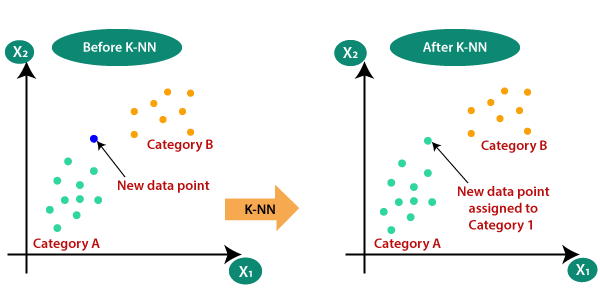

In [ ]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [ ]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data
    """

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [ ]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [ ]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [ ]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [ ]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


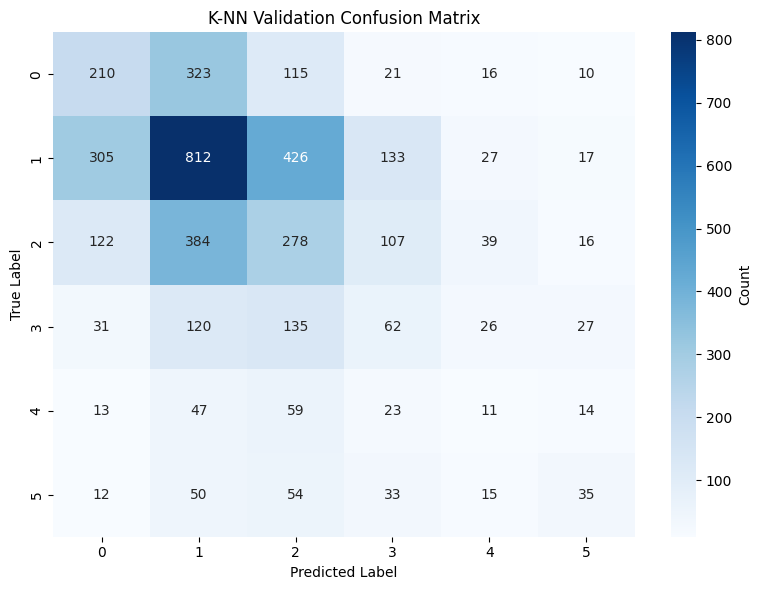

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [ ]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [ ]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [ ]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [ ]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

val%  train  val  NN_mean  NN_std  rand_mean  rand_std
0.1 16484 12 29.43 8.21 16.27 9.39


1 16334 162 32.66 4.1 17.49 4.35


5 15683 813 34.12 0.79 16.11 0.74


10 14884 1612 34.74 1.1 16.86 1.16


25 12369 4127 33.79 0.51 16.16 0.73


50 8226 8270 32.82 0.64 16.64 0.24


75 4167 12329 31.26 0.51 16.83 0.27


90 1628 14868 29.42 0.08 16.79 0.47


99 160 16336 28.19 0.99 16.94 0.33


99.9 13 16483 25.02 3.57 18.08 1.17
test accuracy: 34.91795366795367


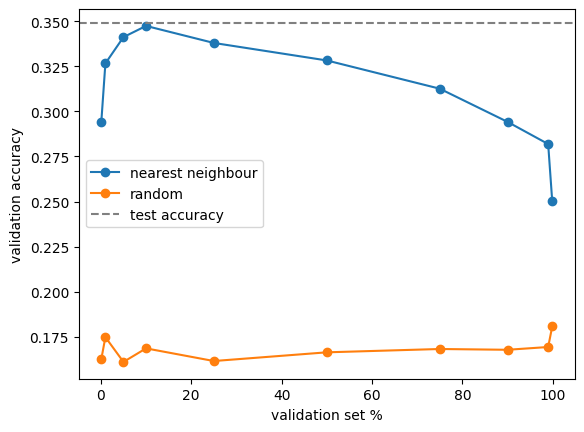

In [ ]:
val_percents = [0.1, 1, 5, 10, 25, 50, 75, 90, 99, 99.9]
nn_mean = []
rand_mean = []

print("val%  train  val  NN_mean  NN_std  rand_mean  rand_std")
for p in val_percents:
    nn_accs = []
    rand_accs = []
    for i in range(5):
        traindata, trainlabel, valdata, vallabel = split(alltraindata, alltrainlabel, 1 - p / 100)
        nn_accs.append(Accuracy(vallabel, NN(traindata, trainlabel, valdata)))
        rand_accs.append(Accuracy(vallabel, RandomClassifier(traindata, trainlabel, valdata)))
    nn_mean.append(np.mean(nn_accs))
    rand_mean.append(np.mean(rand_accs))
    print(p, len(trainlabel), len(vallabel), round(np.mean(nn_accs) * 100, 2), round(np.std(nn_accs) * 100, 2),
          round(np.mean(rand_accs) * 100, 2), round(np.std(rand_accs) * 100, 2))

print("test accuracy:", testAccuracy * 100)

plt.plot(val_percents, nn_mean, marker='o', label='nearest neighbour')
plt.plot(val_percents, rand_mean, marker='o', label='random')
plt.axhline(testAccuracy, linestyle='--', color='gray', label='test accuracy')
plt.xlabel('validation set %')
plt.ylabel('validation accuracy')
plt.legend()
plt.show()

I ran every split 5 times and took the average, the table and graph are above. Test accuracy for nearest neighbour is 34.92%.

1. When the validation set is bigger the train set is smaller, so the nearest neighbour accuracy goes down. It is around 34% for 5% to 25% validation, 32.8% at 50%, 29.4% at 90% and only 25% at 99.9% (13 train samples left). When the validation set is smaller the accuracy stays around 34 to 35% but it starts jumping around. At 0.1% there are only about 12 validation samples so the accuracy changed a lot between runs (std 8.21). The random classifier stays near 16 to 17% (1/6) for almost every split. It only moves around when the validation set is tiny (0.1%, 1%) or when almost nothing is left for training (99.9%).

2. If the validation set is too small the estimate is noisy (std 4.1 at 1% and 8.21 at 0.1%), so it can be far from the test accuracy just by luck. If the train set is too small the model itself is weaker, so the validation accuracy comes out lower than the test accuracy (28.2% at 99% validation and 25% at 99.9%, test is 34.9%). The validation accuracy is closest to the test accuracy when both sets are big enough, around 5% to 25% validation.

3. I think 20 to 25% is good. The validation set then has 3000 to 4000 samples and the std is about 0.5, and the train set still has 75% of the data so the accuracy is close to the test accuracy (33.8% vs 34.9%). 10% also gave a good value here but it was noisier than 25%.

> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(alltraindata, alltrainlabel)
pred1 = knn1.predict(testdata)

knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(alltraindata, alltrainlabel)
pred3 = knn3.predict(testdata)

print("1 nearest neighbour test accuracy:", accuracy_score(testlabel, pred1) * 100, "%")
print("3 nearest neighbour test accuracy:", accuracy_score(testlabel, pred3) * 100, "%")

1 nearest neighbour test accuracy: 34.91795366795367 %
3 nearest neighbour test accuracy: 36.05212355212355 %


1 nearest neighbour gave 34.92% on the test set and 3 nearest neighbour gave 36.05%, so 3 nearest neighbour is about 1.1% better. With 3 neighbours the label is decided by a vote of three points, so one odd neighbour can't decide it alone.

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [ ]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [ ]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


In [ ]:
def FastNN(traindata, trainlabel, testdata):
    # same as NN but much faster
    model = KNeighborsClassifier(n_neighbors=1)
    model.fit(traindata, trainlabel)
    return model.predict(testdata)


def repeat(classifier, splitpercent, iterations):
    # run AverageAccuracy 10 times to see how much the answer moves
    results = []
    for run in range(10):
        results.append(AverageAccuracy(alltraindata, alltrainlabel, splitpercent, iterations, classifier=classifier))
    return np.mean(results) * 100, np.std(results) * 100


print("test accuracy:", testAccuracy * 100)

print("75% train, 25% val")
print("iterations  mean  std")
for it in [1, 2, 5, 10, 20, 50]:
    m, s = repeat(FastNN, 75 / 100, it)
    print(it, round(m, 2), round(s, 2))

print("very small validation set (1% val)")
for it in [1, 10, 50]:
    m, s = repeat(FastNN, 99 / 100, it)
    print(it, round(m, 2), round(s, 2))

print("very small train set (2% train)")
for it in [1, 10, 50]:
    m, s = repeat(FastNN, 2 / 100, it)
    print(it, round(m, 2), round(s, 2))

test accuracy: 34.91795366795367
75% train, 25% val
iterations  mean  std
1 33.93 0.91


2 34.25 0.24


5 34.19 0.31


10 34.13 0.27


20 34.15 0.19


50 34.07 0.04
very small validation set (1% val)
1 35.14 3.69


10 34.55 1.24


50 34.74 0.46
very small train set (2% train)
1 27.93 0.67


10 27.47 0.22


50 27.49 0.16


I ran AverageAccuracy 10 times for each number of iterations and looked at the mean and std (in the cell above). I used a faster 1 nearest neighbour from sklearn (it gives the same predictions as NN) because NN would take too long for this many runs.

1. Yes. With 1 iteration the std between runs was 0.91, with 10 iterations it was 0.27 and with 50 it was 0.04. So the average changes much less from run to run.

2. Only a little. The mean stays around 34.1% for every number of iterations and the test accuracy is 34.92%, so there is still a gap of about 0.8%. Averaging takes out the luck of one split but not this gap. The gap is there because the validation models are trained on 75% of the train data and the test model uses all of it. So the estimate is steadier, but it is a bit lower than the test accuracy.

3. More iterations gives a steadier estimate but the gain gets smaller. The std went from 0.91 to 0.27 by 10 iterations, then 0.19 at 20 and 0.04 at 50. Around 10 to 20 iterations looks enough, more just takes longer.

4. It depends on which one is small. For a small validation set (1%, about 165 samples) yes. One split had std 3.69, with 50 iterations it was 0.46 and the mean (34.74%) was close to the test accuracy. For a small train set (2%) no. The std gets smaller (0.67 to 0.16) but the mean stays at about 27.5%, far below the test accuracy of 34.9%. The model trained on so little data is just worse and averaging does not fix that.

> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

changing the number of splits (75% train, 25% val)
iterations  1NN_mean  1NN_std  3NN_mean  3NN_std


1 33.9 0.54 34.6 0.45


2 34.15 0.33 34.34 0.47


5 33.95 0.29 34.66 0.2


10 34.16 0.15 34.55 0.2


...

10 29.45 30.79


25 31.36 32.0


50 32.96 33.46


75 34.09 34.48


90 34.58 35.08


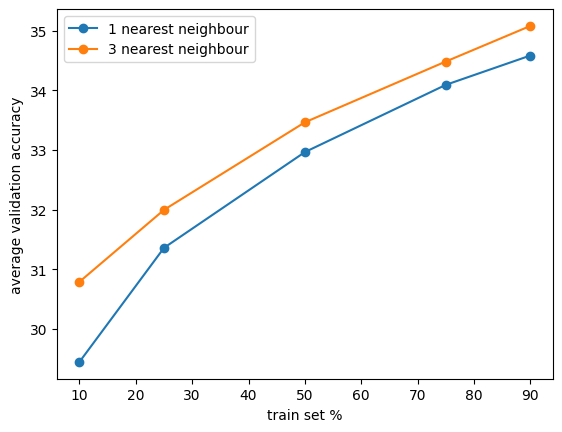

In [ ]:
def KNN3(traindata, trainlabel, testdata):
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(traindata, trainlabel)
    return model.predict(testdata)


print("changing the number of splits (75% train, 25% val)")
print("iterations  1NN_mean  1NN_std  3NN_mean  3NN_std")
for it in [1, 2, 5, 10, 20, 50]:
    m1, s1 = repeat(FastNN, 75 / 100, it)
    m3, s3 = repeat(KNN3, 75 / 100, it)
    print(it, round(m1, 2), round(s1, 2), round(m3, 2), round(s3, 2))

print("changing the split size (10 iterations)")
print("train%  1NN_mean  3NN_mean")
train_percents = [10, 25, 50, 75, 90]
acc1 = []
acc3 = []
for p in train_percents:
    m1, s1 = repeat(FastNN, p / 100, 10)
    m3, s3 = repeat(KNN3, p / 100, 10)
    acc1.append(m1)
    acc3.append(m3)
    print(p, round(m1, 2), round(m3, 2))

plt.plot(train_percents, acc1, marker='o', label='1 nearest neighbour')
plt.plot(train_percents, acc3, marker='o', label='3 nearest neighbour')
plt.xlabel('train set %')
plt.ylabel('average validation accuracy')
plt.legend()
plt.show()

For both classifiers the mean stays the same when the number of splits goes up (about 34.1% for 1NN and 34.6% for 3NN), only the std gets smaller, from about 0.5 with 1 split to 0.1 with 50 splits.

For the split size, accuracy goes up for both when more data is used for training. From 10% to 90% train it goes from 29.5 to 34.6 for 1NN and from 30.8 to 35.1 for 3NN. 3NN is higher than 1NN in every case, by about 0.2 to 1.3 points, and the difference is biggest when the train set is small (10% train). The test set result showed the same thing (36.05% for 3NN and 34.92% for 1NN).